# **Exploratory Data Analysis & Intro**

### *Goal*
- Investigate top-paying roles and skills in the data science industry.
- Use Python to explore a real-live dataset on job postings.
- For job-seekers: use these insights to help find the best job opportunities.

### *Final Deliverables:*
- Create Jupyter Notebookss (showcasing core skills in Python).
- Create a summary page (via README.md) capturing your findings.

### *Questions to Answer*
- What are the most demanded skills for the top 3 most popular data roles?
- How are in-demand skills trending for Data Analysts?
- How well do jobs and skills pay for Data Analysts?
- What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)

I'll be focusing on DE Data Analyst roles, but you can adapt to any of the following:

# **Exploratory Data Analysis for all Data Roles**

In [61]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Roles to Explore

In [62]:
df_DA_DE = df[(df['job_country'] == 'Germany') & (df['job_title'] == 'Data Analyst')]

df_plot = df['job_title_short'].value_counts().to_frame()

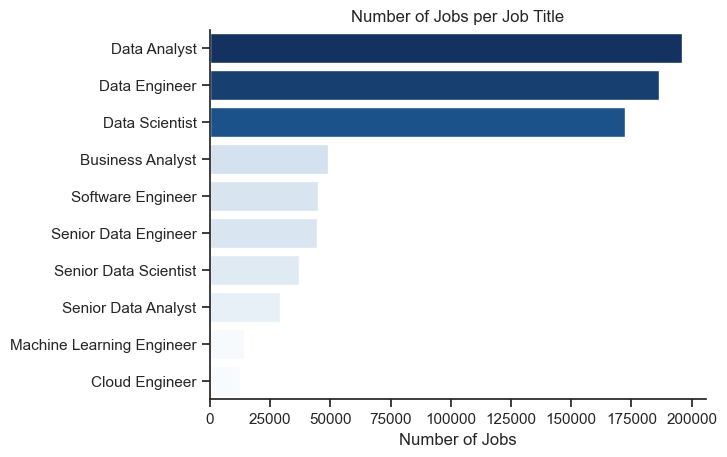

In [63]:
sns.set_theme(style='ticks')

sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='Blues', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Countries to Explore

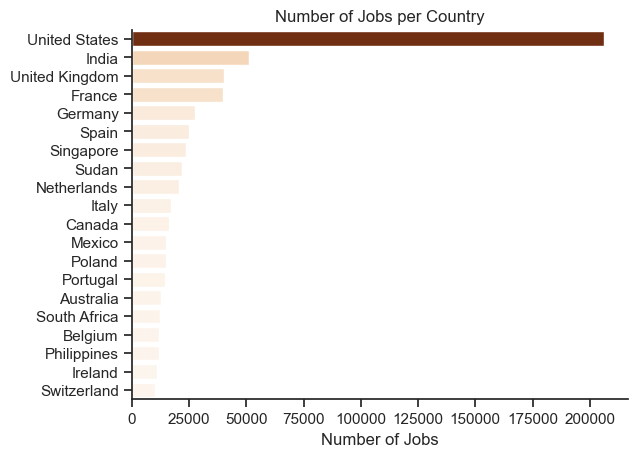

In [64]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='Oranges', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Companies to Explore

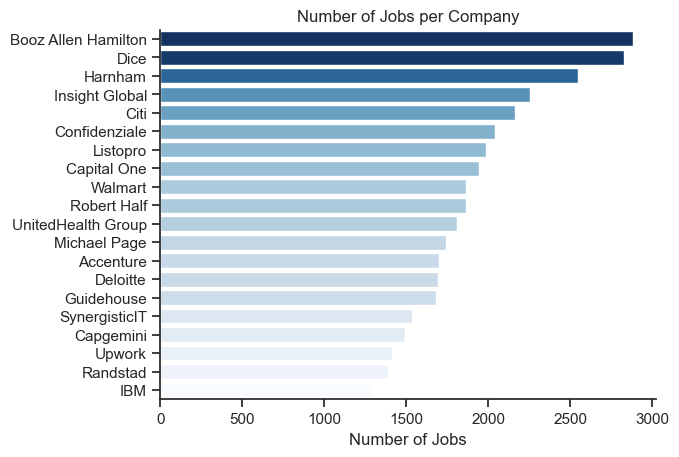

In [65]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='Blues', legend=False)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Job Opportunities

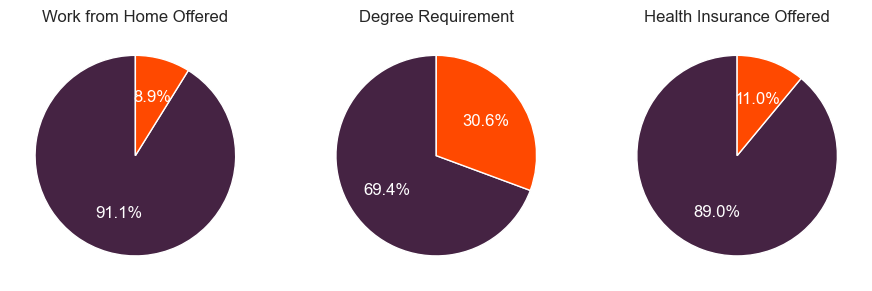

In [66]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90,colors=['#452343','#ff4900'], textprops={'color': 'white'})
    ax[i].set_title(title)

plt.show()

# **Exploratory Data Analysis for Data Analysts in the DE**

In [67]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter for US Data Analyst roles

In [68]:
df_DA_DE = df[(df['job_country'] == 'Germany') & (df['job_title_short'] == 'Data Analyst')]

### Locations to Explore:

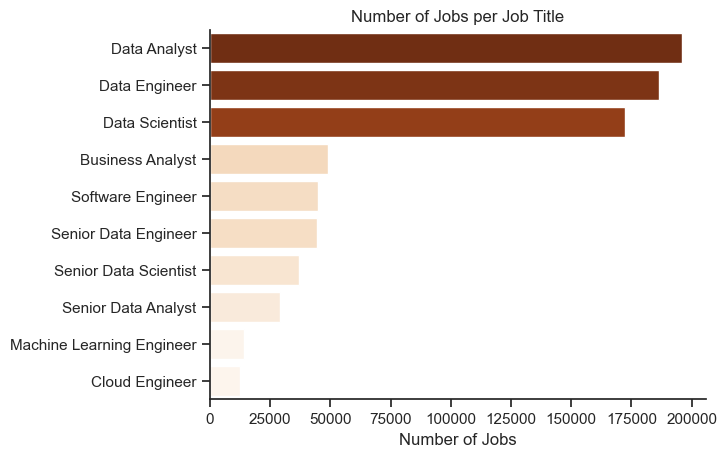

In [69]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='Oranges', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Opportunities

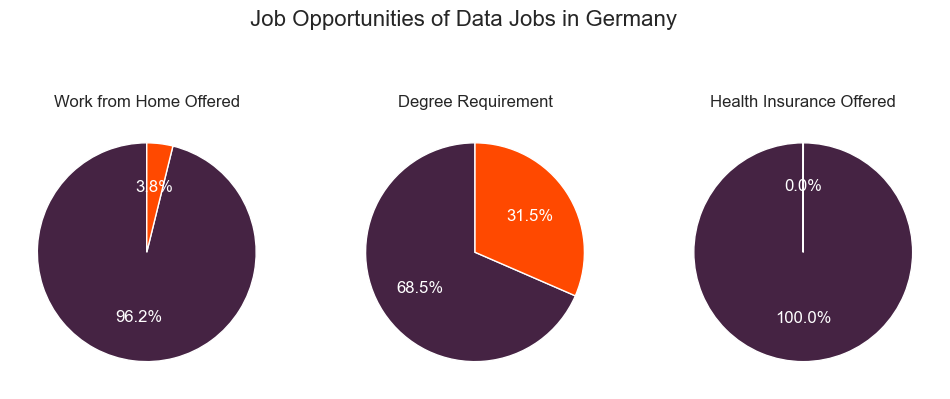

In [70]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_DE[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90, colors=['#452343','#ff4900'], textprops={'color': 'white'})
    ax[i].set_title(title)

plt.suptitle(' Job Opportunities of Data Jobs in Germany', fontsize=16)
plt.show()

### Companies to Explore

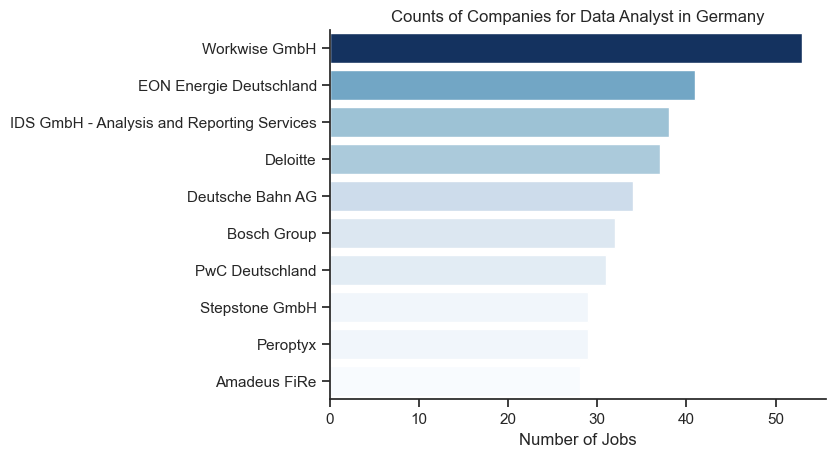

In [71]:
df_plot = df_DA_DE['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='Blues', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in Germany')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()